Plot vars on the BAWLD grid and look for relationships

In [105]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt

import numpy as np

from land_cover.load import plot_dir, load_regrid_BAWLD
from land_cover.plotting import reg_hexplot, add_r2, add_regress, plot_choro_and_hist

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
gdf = load_regrid_BAWLD()

In [5]:
gdf.info(max_cols=500, show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 23469 entries, 0 to 23468
Data columns (total 187 columns):
 #    Column                          Non-Null Count  Dtype   
---   ------                          --------------  -----   
 0    Cell_ID_bawld                   23469 non-null  int64   
 1    Lake_id_glakes                  7804 non-null   float64 
 2    Area_bound_glakes               7804 non-null   float64 
 3    Area_PW_glakes                  23469 non-null  float64 
 4    Continent_glakes                7804 non-null   object  
 5    Lat_glakes                      7804 non-null   float64 
 6    Lon_glakes                      7804 non-null   float64 
 7    GFed_flag_glakes                7804 non-null   float64 
 8    PFed_flag_glakes                7804 non-null   float64 
 9    Endo_flag_glakes                7804 non-null   float64 
 10   Rser_flag_glakes                7804 non-null   float64 
 11   Shape_Leng_glakes               7804 non-null   float64 


# Regression plots

No Concordance in vegetation vars

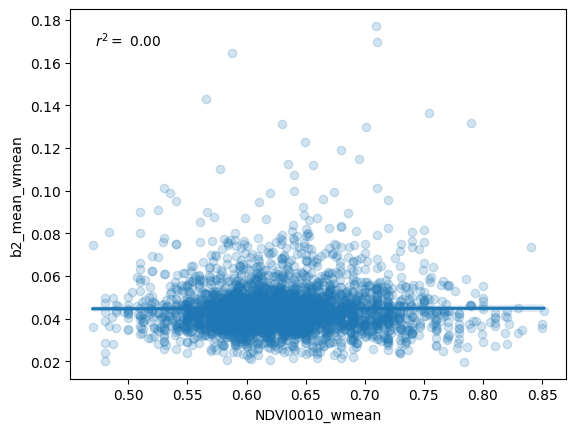

In [16]:
sns.regplot(gdf, x="NDVI0010_wmean", y="b2_mean_wmean", scatter_kws={"alpha": 0.2})
add_r2(gdf.NDVI0010_wmean, gdf.b2_mean_wmean)

No Concordance in change trend

(-0.0015, 0.0015)

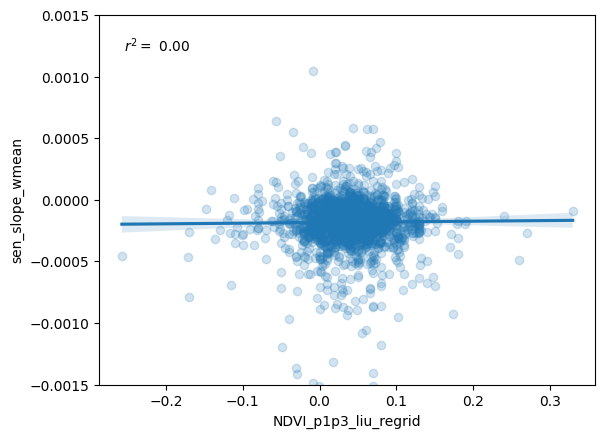

In [ ]:
# Hide a few outliers
sns.regplot(gdf, x="NDVI_p1p3_liu_regrid", y="sen_slope_wmean", scatter_kws={"alpha":0.2})
add_r2(gdf.NDVI_p1p3_liu_regrid, gdf.sen_slope_wmean)
plt.ylim([-0.0015, 0.0015])

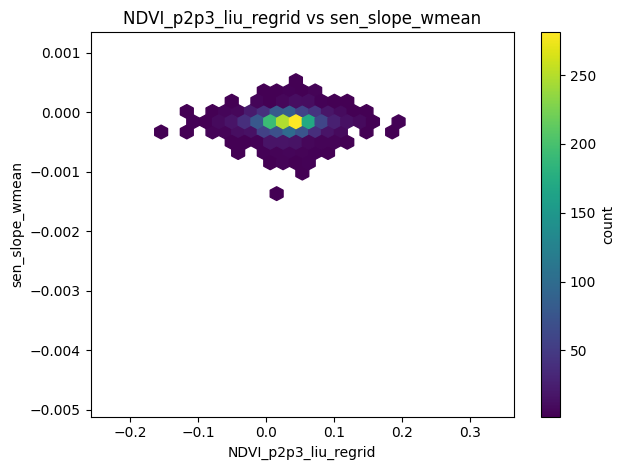

In [12]:
reg_hexplot(gdf, "NDVI_p2p3_liu_regrid", "sen_slope_wmean", mincnt=2)

# Bin by BAWLD class

In [39]:
wetscape_dict = {
    1: "Permafrost Peatlands",
    2: "Sparse Boreal Peatlands",
    3: "Rivers",
    4: "Glaciers",
    5: "Upland Tundra",
    6: "Common Boreal Peatlands",
    7: "Large Lakes",
    8: "Lake-rich wetlands",
    9: "Dominant Boreal Peatlands",
    10: "Wetland-rich Tundra",
    11: "Alpine and Tundra Barrens",
    12: "Wetland and Lake-rich Tundra",
    13: "Lake-rich Shield",
    14: "Upland Boreal",
    15: "Wetland and Lake-rich Yedoma Tundra",
}

In [42]:
def plot_wetscape_bar(gdf, col, plot_dir=None):
    """Bar plot of weighted means (with SEM and counts) by WETSCAPE zone."""
    df = gdf.dropna(subset=["WETSCAPE", col])
    grouped = df.groupby("WETSCAPE")[col]
    stats = grouped.agg(["mean", "sem", "count"]).sort_index()

    if stats.empty:
        print(f"No data available for WETSCAPE and {col}")
        return

    x_labels = [wetscape_dict.get(k, str(k)) for k in stats.index]
    y = stats["mean"].values
    yerr = stats["sem"].values

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(x_labels)), y, yerr=yerr, capsize=4, alpha=0.8)
    plt.xticks(range(len(x_labels)), x_labels, rotation=45, ha="right")
    plt.ylabel(f"Mean {col}")
    plt.xlabel("WETSCAPE")
    plt.title(f"Mean {col} by WETSCAPE (±SEM)")

    for i, cnt in enumerate(stats["count"].astype(int).values):
        plt.text(
            i,
            y[i] + (yerr[i] if not np.isnan(yerr[i]) else 0),
            f"n={cnt}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.tight_layout()
    if plot_dir:
        plt.savefig(f"{plot_dir}/{col}_by_wetscape.png", dpi=200)
    plt.show()

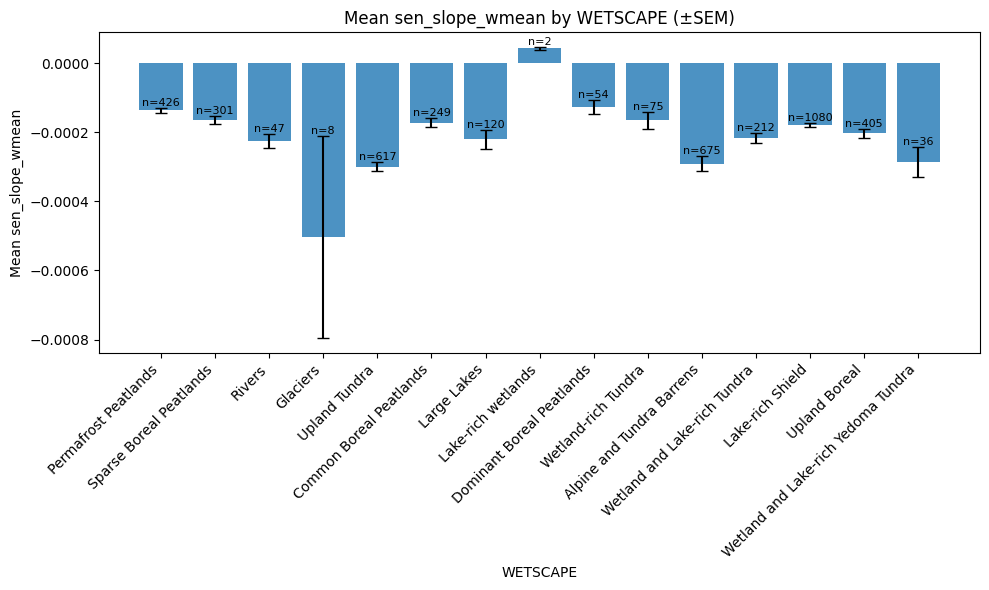

In [43]:
plot_wetscape_bar(gdf, "sen_slope_wmean", plot_dir)

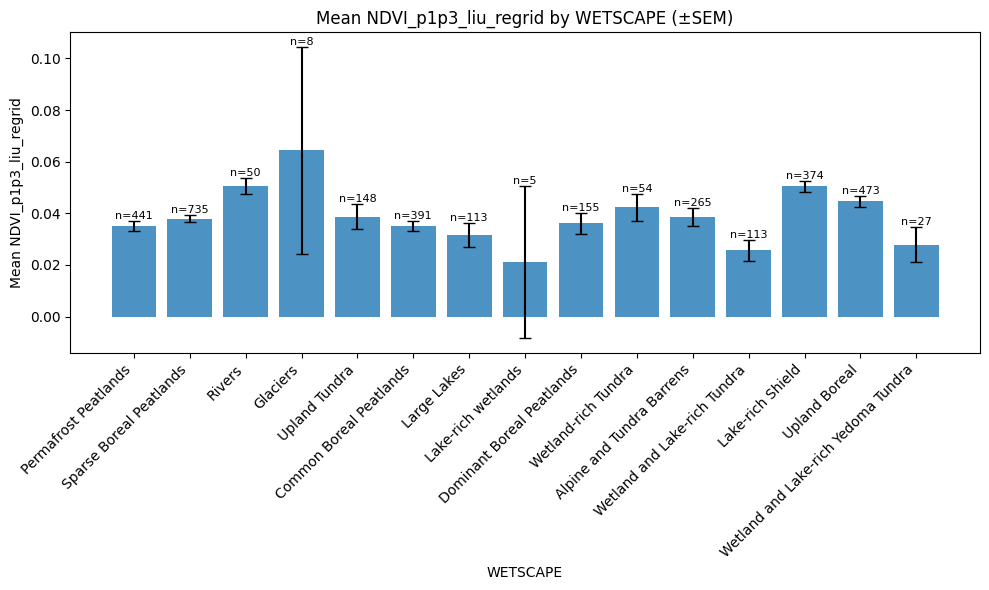

In [44]:
plot_wetscape_bar(gdf, "NDVI_p1p3_liu_regrid", plot_dir)

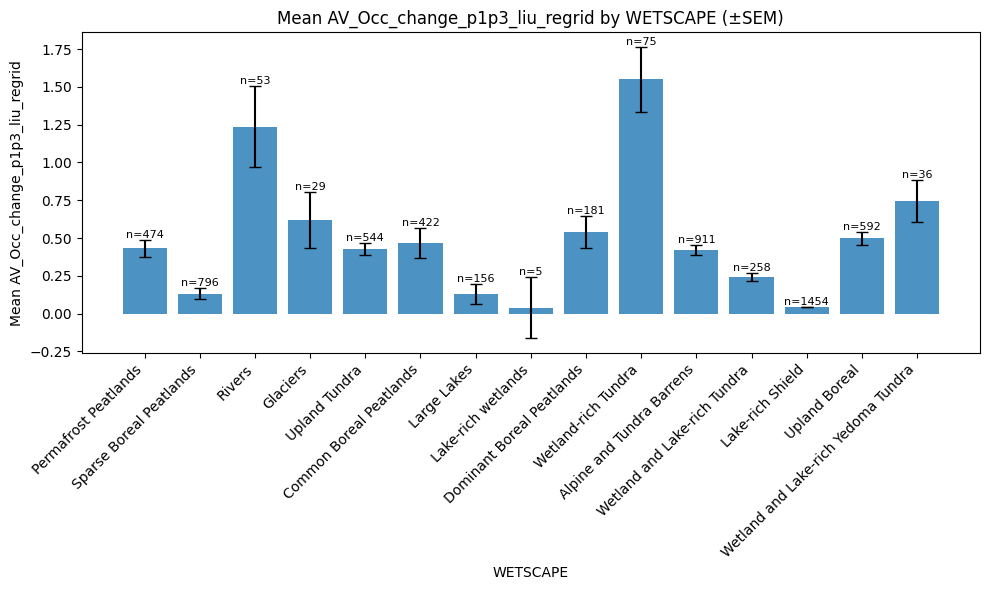

In [101]:
plot_wetscape_bar(gdf, "AV_Occ_change_p1p3_liu_regrid", plot_dir)

## regression based on BAWLD classes

In [103]:
grouped = gdf.groupby("WETSCAPE")[
    ["NDVI_p1p3_liu_regrid", "sen_slope_wmean", "AV_Occ_change_p1p3_liu_regrid"]
].mean()
grouped

,NDVI_p1p3_liu_regrid,sen_slope_wmean,AV_Occ_change_p1p3_liu_regrid
WETSCAPE,,,
1,0.035038,-0.000137,0.431976
2,0.037943,-0.000164,0.131261
3,0.050452,-0.000227,1.236774
4,0.064365,-0.000504,0.619868
5,0.038637,-0.000300,0.426097
6,0.034994,-0.000173,0.467681
7,0.031497,-0.000221,0.129487
8,0.021078,0.000043,0.039310
9,0.036117,-0.000127,0.539645


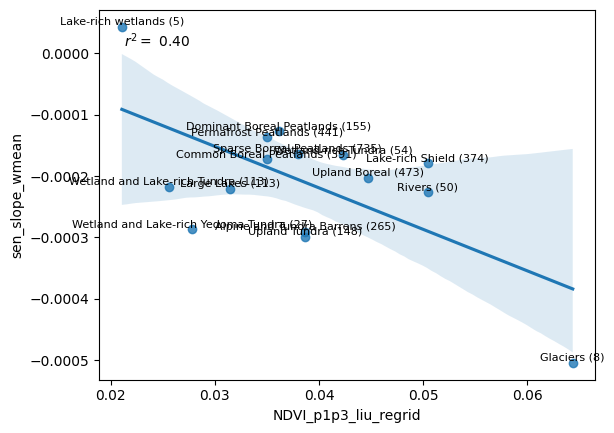

In [76]:
sns.regplot(grouped, x="NDVI_p1p3_liu_regrid", y="sen_slope_wmean")
add_r2(grouped.NDVI_p1p3_liu_regrid, grouped.sen_slope_wmean)
counts = gdf.groupby("WETSCAPE")["NDVI_p1p3_liu_regrid"].count()
for i, (_, row) in enumerate(grouped.reset_index().iterrows()):
    label = f"{wetscape_dict[row.WETSCAPE]} ({counts[row.WETSCAPE]})"
    plt.text(
        row["NDVI_p1p3_liu_regrid"],
        row["sen_slope_wmean"],
        label,
        fontsize=8,
        ha="center",
        va="bottom",
    )

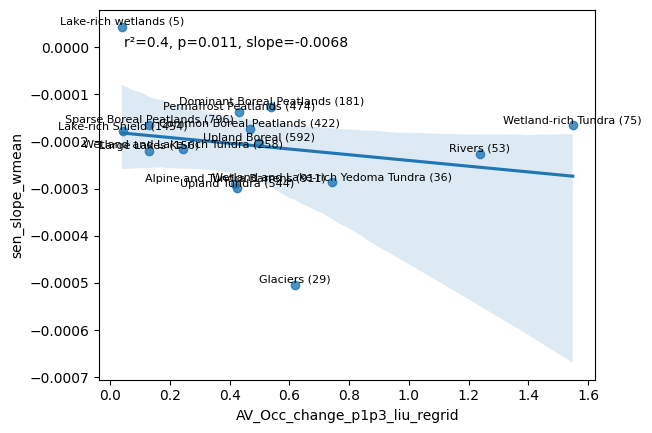

In [113]:
sns.regplot(grouped, x="AV_Occ_change_p1p3_liu_regrid", y="sen_slope_wmean")
add_regress(grouped.NDVI_p1p3_liu_regrid, grouped.sen_slope_wmean)
counts = gdf.groupby("WETSCAPE")["AV_Occ_change_p1p3_liu_regrid"].count()
for i, (_, row) in enumerate(grouped.reset_index().iterrows()):
    label = f"{wetscape_dict[row.WETSCAPE]} ({counts[row.WETSCAPE]})"
    plt.text(
        row["AV_Occ_change_p1p3_liu_regrid"],
        row["sen_slope_wmean"],
        label,
        fontsize=8,
        ha="center",
        va="bottom",
    )

No outliers

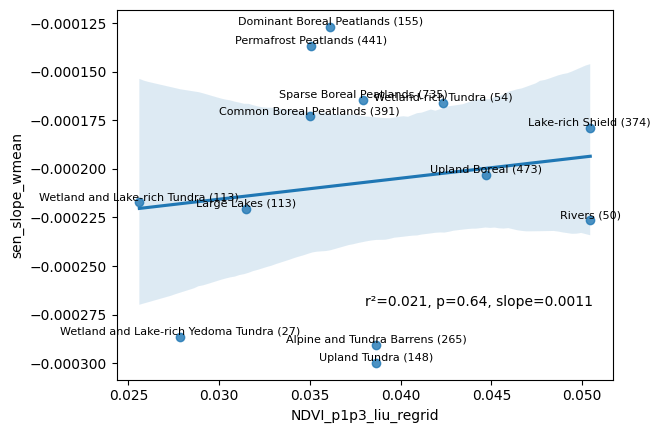

In [116]:
grouped_no_outliers = grouped.drop(index=[4, 8])
sns.regplot(grouped_no_outliers, x="NDVI_p1p3_liu_regrid", y="sen_slope_wmean")
add_regress(grouped_no_outliers.NDVI_p1p3_liu_regrid, grouped_no_outliers.sen_slope_wmean, xy=(0.5, 0.2))
counts = gdf.groupby("WETSCAPE")["NDVI_p1p3_liu_regrid"].count().drop(index=[4, 8])
for i, (_, row) in enumerate(grouped_no_outliers.reset_index().iterrows()):
    label = f"{wetscape_dict[row.WETSCAPE]} ({counts[row.WETSCAPE]})"
    plt.text(
        row["NDVI_p1p3_liu_regrid"],
        row["sen_slope_wmean"],
        label,
        fontsize=8,
        ha="center",
        va="bottom",
    )

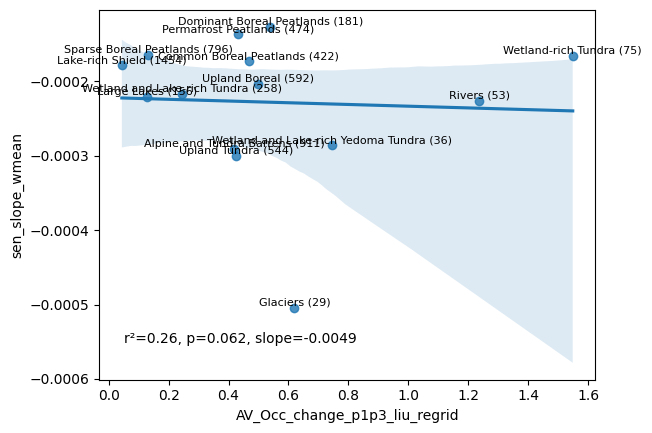

In [112]:
grouped_no_outliers = grouped.drop(index=[8])
sns.regplot(grouped_no_outliers, x="AV_Occ_change_p1p3_liu_regrid", y="sen_slope_wmean")
add_regress(grouped_no_outliers.NDVI_p1p3_liu_regrid, grouped_no_outliers.sen_slope_wmean, xy=(0.05, 0.1))
counts = gdf.groupby("WETSCAPE")["AV_Occ_change_p1p3_liu_regrid"].count()
for i, (_, row) in enumerate(grouped_no_outliers.reset_index().iterrows()):
    label = f"{wetscape_dict[row.WETSCAPE]} ({counts[row.WETSCAPE]})"
    plt.text(
        row["AV_Occ_change_p1p3_liu_regrid"],
        row["sen_slope_wmean"],
        label,
        fontsize=8,
        ha="center",
        va="bottom",
    )

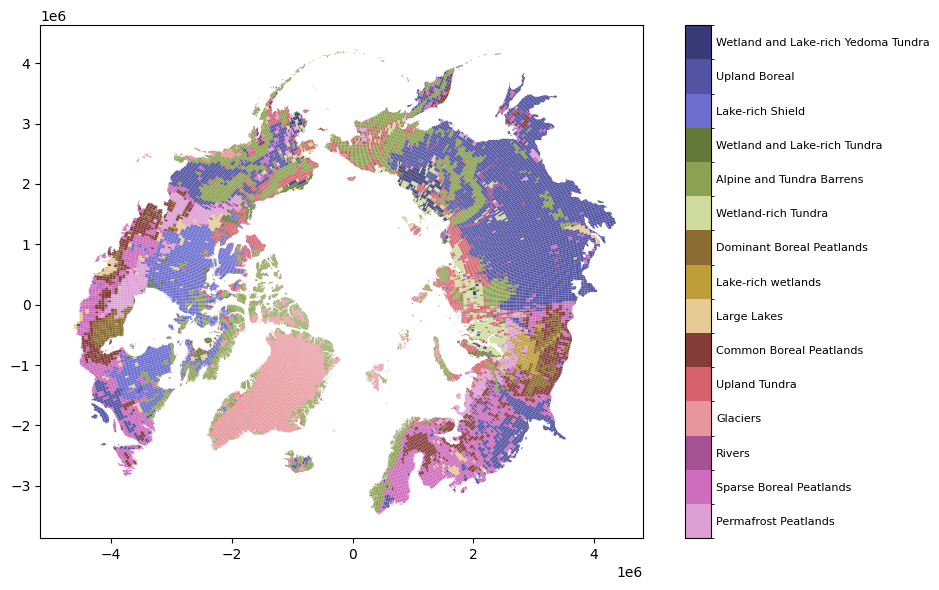

In [95]:
import matplotlib.colors as mcolors

cmap = plt.get_cmap("tab20b_r", 15)  # discrete colormap with 15 colors
norm = mcolors.BoundaryNorm(np.arange(1, 17) - 0.5, cmap.N)  # boundaries for integers 1..15

ax = gdf.plot(column="WETSCAPE", cmap=cmap, norm=norm, legend=False, figsize=(10, 6))

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(1, 16))
cbar.ax.set_yticklabels([wetscape_dict[i] for i in range(1, 16)], fontsize=8)
cbar.ax.tick_params(length=0)
plt.tight_layout()

# Static vars

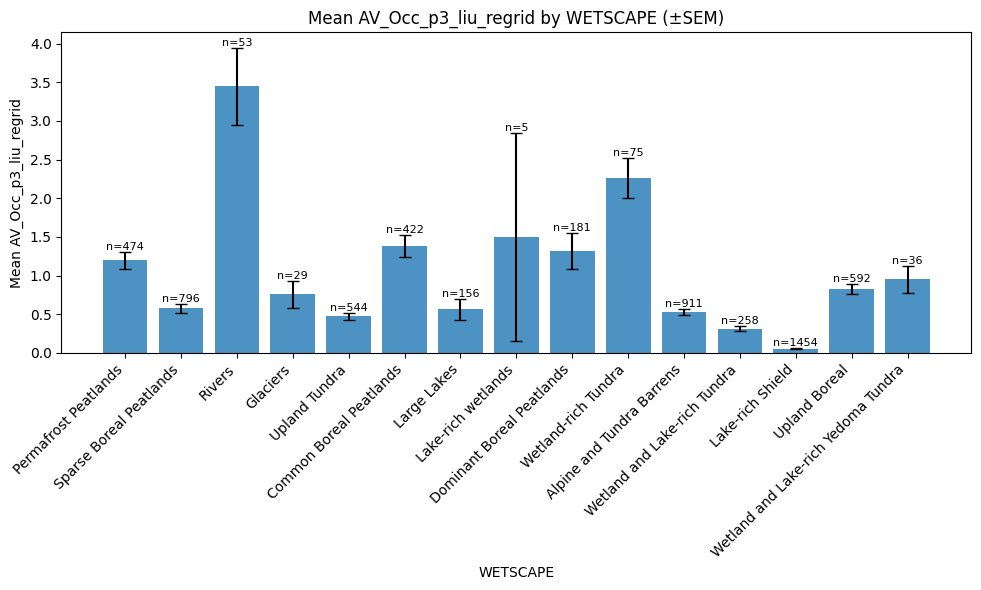

In [96]:
plot_wetscape_bar(gdf, "AV_Occ_p3_liu_regrid", plot_dir)

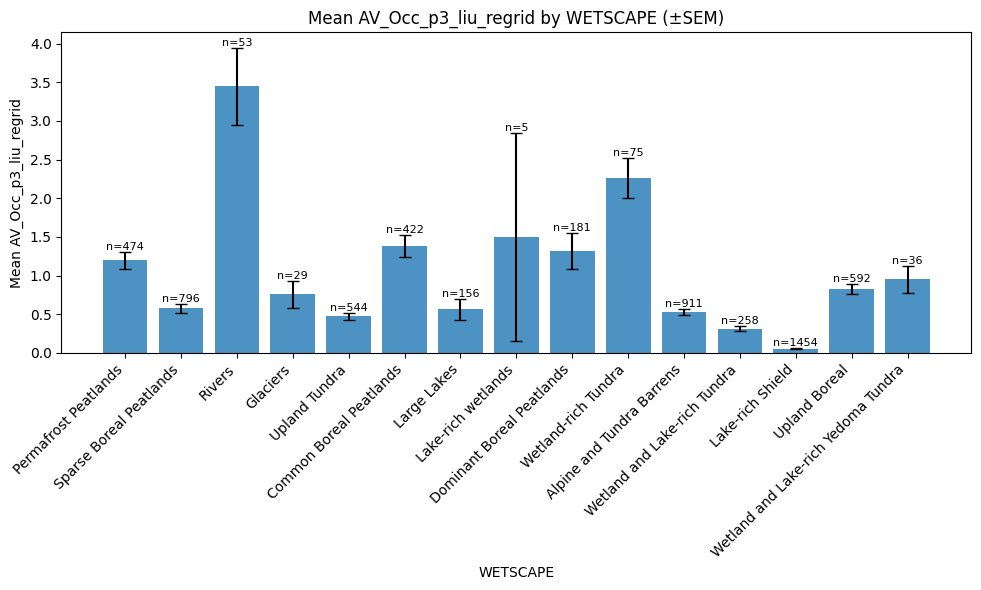

In [ ]:
plot_wetscape_bar(gdf, "AV_Occ_p3_liu_regrid", plot_dir)

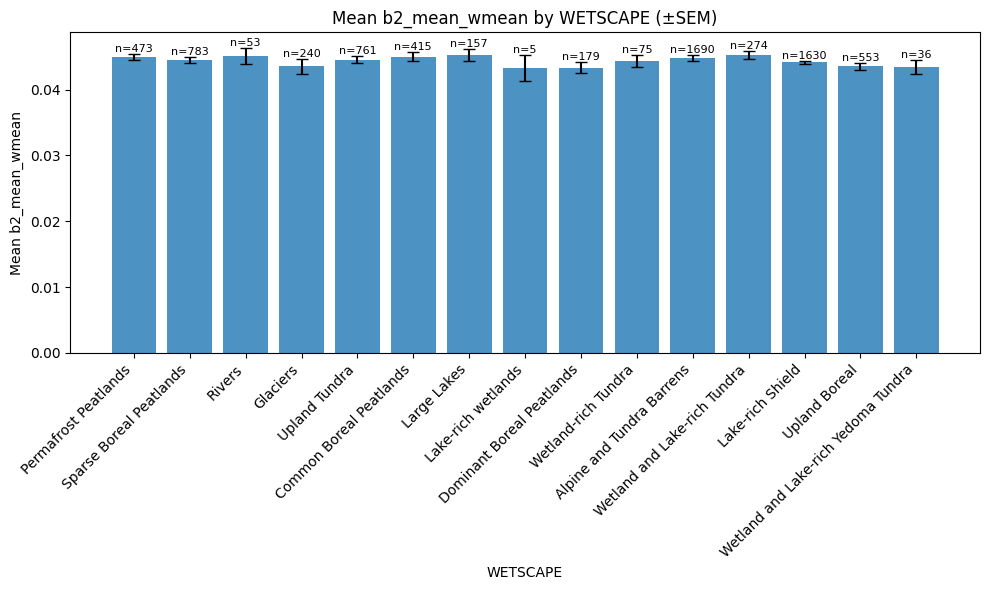

In [97]:
plot_wetscape_bar(gdf, "b2_mean_wmean", plot_dir)

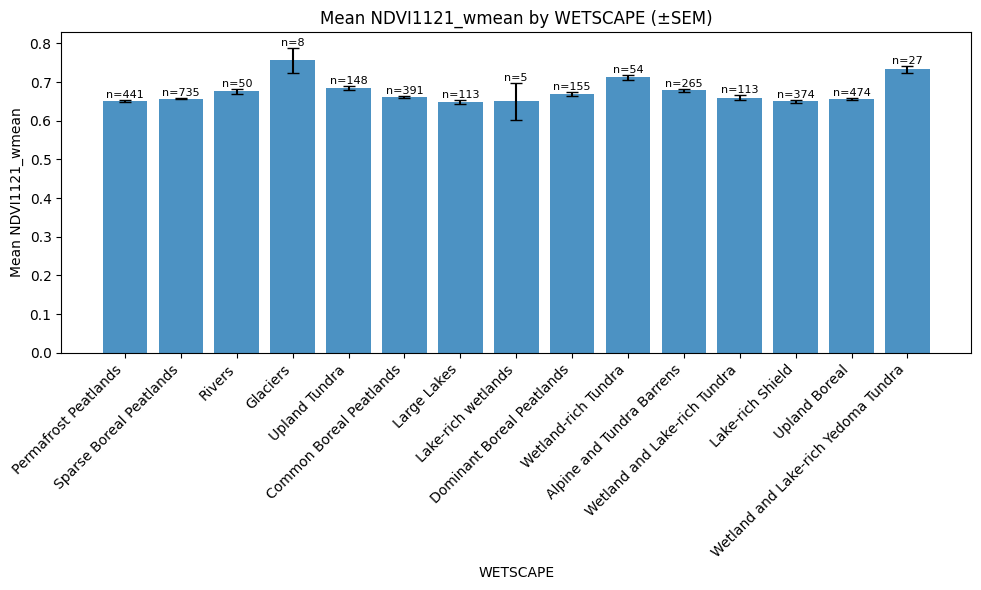

In [98]:
plot_wetscape_bar(gdf, "NDVI1121_wmean", plot_dir)

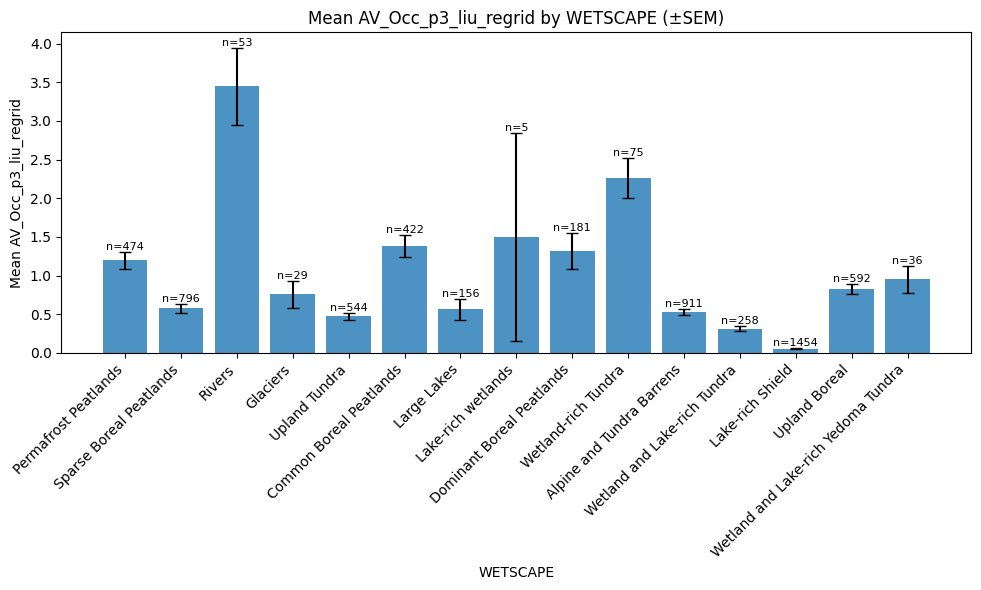

In [99]:
plot_wetscape_bar(gdf, "AV_Occ_p3_liu_regrid", plot_dir)